# 06 — Model Tuning and Final Selection

This notebook tunes the strongest baseline candidates and compares their optimized performance.

Main goals:
- tune shortlisted baseline models
- compare tuned results using cross-validation and test-set metrics
- select the final model for the next stage of the project

In [132]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

import pandas as pd
import numpy as np

from pathlib import Path
import json

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

## 1. Shortlisted models for tuning

Based on the baseline comparison in the previous notebook, the following models were selected for tuning:

- Logistic Regression
- Random Forest
- XGBoost

These models showed the strongest baseline performance and represent different levels of model complexity and interpretability.

## 2. Load the dataset and preprocessing configuration

The raw dataset is loaded again, and the saved preprocessing decisions from earlier notebooks are reused to keep the tuning stage consistent and reproducible.

In [ ]:
DATA_PATH = Path("../data/raw/telco.csv")

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (7043, 50)


,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [ ]:
CONFIG_PATH = Path("../reports/feature_config.json")

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    feature_config = json.load(f)

feature_config

{'target_column': 'target_churn',
 'dropped_columns': ['Customer Status',
  'Churn Category',
  'Churn Reason',
  'Churn Score',
  'Customer ID',
  'Country',
  'State',
  'City',
  'Zip Code',
  'Latitude',
  'Longitude',
  'Quarter',
  'CLTV',
  'Total Revenue',
  'Churn Label'],
 'numeric_features': ['Age',
  'Number of Dependents',
  'Population',
  'Number of Referrals',
  'Tenure in Months',
  'Avg Monthly Long Distance Charges',
  'Avg Monthly GB Download',
  'Monthly Charge',
  'Total Charges',
  'Total Refunds',
  'Total Extra Data Charges',
  'Total Long Distance Charges',
  'Satisfaction Score'],
 'categorical_features': ['Gender',
  'Under 30',
  'Senior Citizen',
  'Married',
  'Dependents',
  'Referred a Friend',
  'Offer',
  'Phone Service',
  'Multiple Lines',
  'Internet Service',
  'Internet Type',
  'Online Security',
  'Online Backup',
  'Device Protection Plan',
  'Premium Tech Support',
  'Streaming TV',
  'Streaming Movies',
  'Streaming Music',
  'Unlimited Data

## 3. Rebuild the modeling dataset

The target variable and the previously defined preprocessing decisions are applied again so that tuning is performed on the same baseline feature set used in the model comparison stage.

In [ ]:
df["target_churn"] = df["Churn Label"].map({"No": 0, "Yes": 1})

object_cols = df.select_dtypes(include="object").columns.tolist()
df[object_cols] = df[object_cols].replace("None", np.nan)
df[object_cols] = df[object_cols].replace(r"^\s*$", np.nan, regex=True)

df[["Churn Label", "target_churn"]].sample(6)

,Churn Label,target_churn
3138,No,0
2260,Yes,1
4162,No,0
1414,Yes,1
4149,No,0
6339,No,0


In [ ]:
drop_cols = feature_config["dropped_columns"]

baseline_df = df.drop(columns=drop_cols).copy()

print("Baseline shape:", baseline_df.shape)
baseline_df.sample(6)

Baseline shape: (7043, 36)


,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Population,Referred a Friend,Number of Referrals,...,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Satisfaction Score,target_churn
673,Male,66,No,Yes,No,No,0,2355,No,0,...,Two Year,No,Bank Withdrawal,69.65,1043.30,0.00,0,366.40,3,0
6377,Male,42,No,No,No,No,0,1785,No,0,...,Two Year,Yes,Bank Withdrawal,108.95,4025.50,0.00,0,702.45,3,0
224,Male,79,No,Yes,No,No,0,30933,No,0,...,Month-to-Month,Yes,Bank Withdrawal,91.40,449.75,0.00,0,22.95,1,1
5796,Female,25,Yes,No,No,Yes,1,44442,No,0,...,One Year,No,Credit Card,19.45,921.30,0.00,0,2236.36,5,0
3230,Male,30,No,No,No,No,0,62848,No,0,...,One Year,Yes,Bank Withdrawal,75.35,2243.90,2.24,0,107.01,3,0
5949,Male,43,No,No,Yes,No,0,27959,Yes,1,...,Month-to-Month,No,Credit Card,89.70,4952.95,41.66,0,212.24,4,0


## 3.1 Define features and target

The cleaned baseline dataset is separated into input features (`X`) and target labels (`y`) for tuning and final model evaluation.

In [ ]:
X = baseline_df.drop(columns=["target_churn"])
y = baseline_df["target_churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 35)
y shape: (7043,)


## 3.2 Restore feature groups

Numeric and categorical feature groups are loaded from the saved preprocessing configuration so that the same pipeline logic can be reused during tuning.

In [ ]:
numeric_features = feature_config["numeric_features"]
categorical_features = feature_config["categorical_features"]

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 13
Categorical features: 22


## 4. Train-test split

The dataset is divided into training and test sets.

The test set is kept untouched for final tuned-model evaluation, while tuning is performed using cross-validation on the training data.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5634, 35)
X_test : (1409, 35)
y_train: (5634,)
y_test : (1409,)


## 5. Cross-validation setup

Stratified cross-validation is used during tuning to preserve the class distribution of the churn target across folds.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

## 6. Rebuild preprocessing pipelines

The same numeric and categorical preprocessing structure from the baseline stage is reused here to ensure consistency between model comparison and tuning.

In [ ]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [ ]:
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

categorical_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])

In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Number of Dependents', 'Population',
                                  'Number of Referrals', 'Tenure in Months',
                                  'Avg Monthly Long Distance Charges',
                                  'Avg Monthly GB Download', 'Monthly Charge',
                                  'Total Charges', 'Total Refunds',
                                  'Total Extra Data Charges',
                                  'Total Long Distanc...
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Gender', 'Under 30', 'Senior Citizen',
                                  'Married', 'Dependents', 'Referred a Friend',
                                  'Offer', 'Phone Service', 'Multiple Lines',
                                  'Internet Service', 'Internet Type',
                                  'Online Security', 'Online Backup',
                                  'Device Protection Plan',
                                  'Premium Tech Support', 'Streaming TV',
                                  'Streaming Movies', 'Streaming Music',
                                  'Unlimited Data', 'Contract',
                                  'Paperless Billing', 'Payment Method'])])

## 7. Tuning strategy

The shortlisted models are tuned using different search strategies based on their complexity.

For **Logistic Regression**, `GridSearchCV` is used because the parameter space is relatively small and can be explored more systematically.

For **Random Forest** and **XGBoost**, `RandomizedSearchCV` is preferred because these models have a larger hyperparameter space, and a focused randomized search is more practical at this stage.

F1-score is used as the main optimization metric because churn prediction requires balancing precision and recall rather than relying on accuracy alone.

## 8. Tune Logistic Regression

Logistic Regression is tuned first because it performed strongly in the baseline comparison and remains one of the most interpretable models in the project.

Its parameter space is relatively small, so a focused grid search can be used to test whether modest adjustments improve the baseline performance.

In [ ]:
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

logreg_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Number of Dependents',
                                                   'Population',
                                                   'Number of Referrals',
                                                   'Tenure in Months',
                                                   'Avg Monthly Long Distance '
                                                   'Charges',
                                                   'Avg Monthly GB Download',
                                                   'Monthly Charge',
                                                   'Total Charges',
                                                   'Total Refunds',
                                                   'Total E...
                                                   'Dependents',
                                                   'Referred a Friend', 'Offer',
                                                   'Phone Service',
                                                   'Multiple Lines',
                                                   'Internet Service',
                                                   'Internet Type',
                                                   'Online Security',
                                                   'Online Backup',
                                                   'Device Protection Plan',
                                                   'Premium Tech Support',
                                                   'Streaming TV',
                                                   'Streaming Movies',
                                                   'Streaming Music',
                                                   'Unlimited Data', 'Contract',
                                                   'Paperless Billing',
                                                   'Payment Method'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

### Logistic Regression tuning choices

A small parameter grid is used to test a few reasonable variations of the baseline model.

The search focuses on:
- `C`, to control the strength of regularization
- `class_weight`, to check whether giving more importance to the minority churn class improves recall and F1-score

This is treated as a focused improvement step rather than a large exhaustive search.

In [ ]:
logreg_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__class_weight": [None, "balanced"]
}

logreg_param_grid

{'classifier__C': [0.01, 0.1, 1, 10],
 'classifier__class_weight': [None, 'balanced']}

### Why GridSearchCV was used here

For Logistic Regression, the parameter space is small enough to evaluate systematically.

Because only a limited number of meaningful combinations are being tested, `GridSearchCV` is appropriate at this stage and keeps the tuning process transparent.

In [ ]:
logreg_grid = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=logreg_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

logreg_grid

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'Number '
                                                                          'of '
                                                                          'Dependents',
                                                                          'Population',
                                                                          'Number '
                                                                          'of '
                                                                          'Referrals',
                                                                          'Tenure '
                                                                          'in '
                                                                          'Months',
                                                                          'Avg '
                                                                          'Monthly '
                                                                          '...
                                                                          'Protection '
                                                                          'Plan',
                                                                          'Premium '
                                                                          'Tech '
                                                                          'Support',
                                                                          'Streaming '
                                                                          'TV',
                                                                          'Streaming '
                                                                          'Movies',
                                                                          'Streaming '
                                                                          'Music',
                                                                          'Unlimited '
                                                                          'Data',
                                                                          'Contract',
                                                                          'Paperless '
                                                                          'Billing',
                                                                          'Payment '
                                                                          'Method'])])),
                                       ('classifier',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.01, 0.1, 1, 10],
                         'classifier__class_weight': [None, 'balanced']},
             scoring='f1')

In [ ]:
logreg_grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'Number '
                                                                          'of '
                                                                          'Dependents',
                                                                          'Population',
                                                                          'Number '
                                                                          'of '
                                                                          'Referrals',
                                                                          'Tenure '
                                                                          'in '
                                                                          'Months',
                                                                          'Avg '
                                                                          'Monthly '
                                                                          '...
                                                                          'Protection '
                                                                          'Plan',
                                                                          'Premium '
                                                                          'Tech '
                                                                          'Support',
                                                                          'Streaming '
                                                                          'TV',
                                                                          'Streaming '
                                                                          'Movies',
                                                                          'Streaming '
                                                                          'Music',
                                                                          'Unlimited '
                                                                          'Data',
                                                                          'Contract',
                                                                          'Paperless '
                                                                          'Billing',
                                                                          'Payment '
                                                                          'Method'])])),
                                       ('classifier',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.01, 0.1, 1, 10],
                         'classifier__class_weight': [None, 'balanced']},
             scoring='f1')

In [ ]:
print("Best Parameters:", logreg_grid.best_params_)
print("Best CV F1 Score:", round(logreg_grid.best_score_, 4))

Best Parameters: {'classifier__C': 10, 'classifier__class_weight': None}
Best CV F1 Score: 0.9273


### Evaluate the tuned Logistic Regression model

After cross-validated tuning on the training set, the best Logistic Regression configuration is evaluated on the untouched test set.

In [ ]:
best_logreg_model = logreg_grid.best_estimator_

logreg_y_pred = best_logreg_model.predict(X_test)
logreg_y_proba = best_logreg_model.predict_proba(X_test)[:, 1]

logreg_results = {
    "model": "Tuned Logistic Regression",
    "best_cv_f1": logreg_grid.best_score_,
    "test_accuracy": accuracy_score(y_test, logreg_y_pred),
    "test_precision": precision_score(y_test, logreg_y_pred),
    "test_recall": recall_score(y_test, logreg_y_pred),
    "test_f1": f1_score(y_test, logreg_y_pred),
    "test_roc_auc": roc_auc_score(y_test, logreg_y_proba)
}

pd.DataFrame([logreg_results]).round(4)

,model,best_cv_f1,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,Tuned Logistic Regression,0.9273,0.9624,0.9521,0.9037,0.9273,0.9923


In [ ]:
print(classification_report(y_test, logreg_y_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97      1035
           1       0.95      0.90      0.93       374

    accuracy                           0.96      1409
   macro avg       0.96      0.94      0.95      1409
weighted avg       0.96      0.96      0.96      1409



In [ ]:
logreg_cm = confusion_matrix(y_test, logreg_y_pred)
logreg_cm

array([[1018,   17],
       [  36,  338]], dtype=int64)

## Interpretation of tuned Logistic Regression

The tuned Logistic Regression model produced results that were extremely close to the baseline version.

Although the tuned configuration slightly changed some test-set metrics, the differences were minimal in practical terms. This suggests that the original baseline Logistic Regression model was already strong, and limited grid tuning did not lead to a meaningful performance gain.

As a result, Logistic Regression remains a stable benchmark, but the tuning stage does not materially change its role in the model comparison.

## 9. Tune Random Forest

Random Forest is tuned next because it achieved the strongest cross-validated baseline performance.

Unlike Logistic Regression, tree-based ensemble models often benefit more noticeably from hyperparameter tuning. For that reason, a focused randomized search is used to test whether Random Forest can improve upon its already strong baseline results.

In [ ]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

rf_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Number of Dependents',
                                                   'Population',
                                                   'Number of Referrals',
                                                   'Tenure in Months',
                                                   'Avg Monthly Long Distance '
                                                   'Charges',
                                                   'Avg Monthly GB Download',
                                                   'Monthly Charge',
                                                   'Total Charges',
                                                   'Total Refunds',
                                                   'Total E...
                                                   'Dependents',
                                                   'Referred a Friend', 'Offer',
                                                   'Phone Service',
                                                   'Multiple Lines',
                                                   'Internet Service',
                                                   'Internet Type',
                                                   'Online Security',
                                                   'Online Backup',
                                                   'Device Protection Plan',
                                                   'Premium Tech Support',
                                                   'Streaming TV',
                                                   'Streaming Movies',
                                                   'Streaming Music',
                                                   'Unlimited Data', 'Contract',
                                                   'Paperless Billing',
                                                   'Payment Method'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

### Random Forest tuning choices

A focused hyperparameter space is used to test a few important aspects of the model:

- `n_estimators` controls the number of trees
- `max_depth` controls how deep the trees are allowed to grow
- `min_samples_split` and `min_samples_leaf` help limit overfitting
- `class_weight` checks whether giving more importance to the churn class improves model balance

The goal here is not to search every possible combination, but to test whether reasonable adjustments improve the baseline Random Forest performance.

In [ ]:
rf_param_dist = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 10, 20, 30],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__class_weight": [None, "balanced"]
}

rf_param_dist

{'classifier__n_estimators': [100, 200, 300],
 'classifier__max_depth': [None, 10, 20, 30],
 'classifier__min_samples_split': [2, 5, 10],
 'classifier__min_samples_leaf': [1, 2, 4],
 'classifier__class_weight': [None, 'balanced']}

### Why RandomizedSearchCV was used here

Random Forest has a wider hyperparameter space than Logistic Regression, so a full grid search would be unnecessarily heavy at this stage.

A randomized search makes it possible to explore a meaningful set of parameter combinations while keeping the tuning process practical.

In [50]:
rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=15,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

rf_search

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Number '
                                                                                'of '
                                                                                'Dependents',
                                                                                'Population',
                                                                                'Number '
                                                                                'of '
                                                                                'Referrals',
                                                                                'Tenure '
                                                                                'in '
                                                                                'Months',
                                                                                'Avg '
                                                                                'Mon...
                                                                                'Payment '
                                                                                'Method'])])),
                                             ('classifier',
                                              RandomForestClassifier(random_state=42))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'classifier__class_weight': [None,
                                                                     'balanced'],
                                        'classifier__max_depth': [None, 10, 20,
                                                                  30],
                                        'classifier__min_samples_leaf': [1, 2,
                                                                         4],
                                        'classifier__min_samples_split': [2, 5,
                                                                          10],
                                        'classifier__n_estimators': [100, 200,
                                                                     300]},
                   random_state=42, scoring='f1')

In [51]:
rf_search.fit(X_train, y_train)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Number '
                                                                                'of '
                                                                                'Dependents',
                                                                                'Population',
                                                                                'Number '
                                                                                'of '
                                                                                'Referrals',
                                                                                'Tenure '
                                                                                'in '
                                                                                'Months',
                                                                                'Avg '
                                                                                'Mon...
                                                                                'Payment '
                                                                                'Method'])])),
                                             ('classifier',
                                              RandomForestClassifier(random_state=42))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'classifier__class_weight': [None,
                                                                     'balanced'],
                                        'classifier__max_depth': [None, 10, 20,
                                                                  30],
                                        'classifier__min_samples_leaf': [1, 2,
                                                                         4],
                                        'classifier__min_samples_split': [2, 5,
                                                                          10],
                                        'classifier__n_estimators': [100, 200,
                                                                     300]},
                   random_state=42, scoring='f1')

In [52]:
print("Best Parameters:", rf_search.best_params_)
print("Best CV F1 Score:", round(rf_search.best_score_, 4))

Best Parameters: {'classifier__n_estimators': 200, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 1, 'classifier__max_depth': 30, 'classifier__class_weight': 'balanced'}
Best CV F1 Score: 0.9313


### Evaluate the tuned Random Forest model

After cross-validated tuning on the training set, the best Random Forest configuration is evaluated on the untouched test set.

In [53]:
best_rf_model = rf_search.best_estimator_

rf_y_pred = best_rf_model.predict(X_test)
rf_y_proba = best_rf_model.predict_proba(X_test)[:, 1]

rf_results = {
    "model": "Tuned Random Forest",
    "best_cv_f1": rf_search.best_score_,
    "test_accuracy": accuracy_score(y_test, rf_y_pred),
    "test_precision": precision_score(y_test, rf_y_pred),
    "test_recall": recall_score(y_test, rf_y_pred),
    "test_f1": f1_score(y_test, rf_y_pred),
    "test_roc_auc": roc_auc_score(y_test, rf_y_proba)
}

pd.DataFrame([rf_results]).round(4)

,model,best_cv_f1,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,Tuned Random Forest,0.9313,0.9595,0.9621,0.8824,0.9205,0.9873


In [54]:
print(classification_report(y_test, rf_y_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97      1035
           1       0.96      0.88      0.92       374

    accuracy                           0.96      1409
   macro avg       0.96      0.93      0.95      1409
weighted avg       0.96      0.96      0.96      1409



In [55]:
rf_cm = confusion_matrix(y_test, rf_y_pred)
rf_cm

array([[1022,   13],
       [  44,  330]], dtype=int64)

## Interpretation of tuned Random Forest

The tuned Random Forest model produced only marginal changes relative to the baseline version.

Its cross-validated F1-score improved slightly, which suggests that the model remained strong during training-time validation. However, this improvement did not translate into a meaningful gain on the held-out test set.

Compared with Logistic Regression, the tuned Random Forest still showed a less balanced final performance. In particular, it maintained very high precision but lower recall for the churn class, meaning that it continued to miss more at-risk customers.

Overall, Random Forest remains a strong candidate from a cross-validation perspective, but its tuned version does not clearly outperform Logistic Regression on the test set. This suggests that the baseline Random Forest was already strong, and the current tuning range did not lead to a substantial practical improvement.

## 10. Tune XGBoost

XGBoost is tuned next because it remained one of the strongest baseline candidates and represents a more advanced boosting-based approach for tabular classification.

Unlike Logistic Regression, XGBoost has a wider hyperparameter space, so a focused randomized search is used to test whether moderate tuning can improve its already strong baseline performance.

In [56]:
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

xgb_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Number of Dependents',
                                                   'Population',
                                                   'Number of Referrals',
                                                   'Tenure in Months',
                                                   'Avg Monthly Long Distance '
                                                   'Charges',
                                                   'Avg Monthly GB Download',
                                                   'Monthly Charge',
                                                   'Total Charges',
                                                   'Total Refunds',
                                                   'Total E...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

### XGBoost tuning choices

A focused hyperparameter space is used to test a few important aspects of the model:

- `n_estimators` controls the number of boosting rounds
- `max_depth` controls tree complexity
- `learning_rate` controls how quickly the model learns
- `subsample` reduces overfitting by training on row samples
- `colsample_bytree` reduces overfitting by sampling features per tree

The goal is not to search every possible combination, but to test whether a practical tuning range improves the baseline XGBoost model.

In [57]:
xgb_param_dist = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [3, 5, 7],
    "classifier__learning_rate": [0.01, 0.05, 0.1],
    "classifier__subsample": [0.8, 0.9, 1.0],
    "classifier__colsample_bytree": [0.8, 0.9, 1.0]
}

xgb_param_dist

{'classifier__n_estimators': [100, 200, 300],
 'classifier__max_depth': [3, 5, 7],
 'classifier__learning_rate': [0.01, 0.05, 0.1],
 'classifier__subsample': [0.8, 0.9, 1.0],
 'classifier__colsample_bytree': [0.8, 0.9, 1.0]}

### Why RandomizedSearchCV was used here

XGBoost has a broader hyperparameter space than Logistic Regression, so a full grid search would be unnecessarily heavy for this stage of the project.

A randomized search provides a practical way to explore meaningful combinations while keeping the workflow manageable.

In [58]:
xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_dist,
    n_iter=15,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

xgb_search

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Number '
                                                                                'of '
                                                                                'Dependents',
                                                                                'Population',
                                                                                'Number '
                                                                                'of '
                                                                                'Referrals',
                                                                                'Tenure '
                                                                                'in '
                                                                                'Months',
                                                                                'Avg '
                                                                                'Mon...
                                                            multi_strategy=None,
                                                            n_estimators=None,
                                                            n_jobs=None,
                                                            num_parallel_tree=None, ...))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'classifier__colsample_bytree': [0.8,
                                                                         0.9,
                                                                         1.0],
                                        'classifier__learning_rate': [0.01,
                                                                      0.05,
                                                                      0.1],
                                        'classifier__max_depth': [3, 5, 7],
                                        'classifier__n_estimators': [100, 200,
                                                                     300],
                                        'classifier__subsample': [0.8, 0.9,
                                                                  1.0]},
                   random_state=42, scoring='f1')

In [59]:
xgb_search.fit(X_train, y_train)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Number '
                                                                                'of '
                                                                                'Dependents',
                                                                                'Population',
                                                                                'Number '
                                                                                'of '
                                                                                'Referrals',
                                                                                'Tenure '
                                                                                'in '
                                                                                'Months',
                                                                                'Avg '
                                                                                'Mon...
                                                            multi_strategy=None,
                                                            n_estimators=None,
                                                            n_jobs=None,
                                                            num_parallel_tree=None, ...))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'classifier__colsample_bytree': [0.8,
                                                                         0.9,
                                                                         1.0],
                                        'classifier__learning_rate': [0.01,
                                                                      0.05,
                                                                      0.1],
                                        'classifier__max_depth': [3, 5, 7],
                                        'classifier__n_estimators': [100, 200,
                                                                     300],
                                        'classifier__subsample': [0.8, 0.9,
                                                                  1.0]},
                   random_state=42, scoring='f1')

In [60]:
print("Best Parameters:", xgb_search.best_params_)
print("Best CV F1 Score:", round(xgb_search.best_score_, 4))

Best Parameters: {'classifier__subsample': 0.8, 'classifier__n_estimators': 300, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.01, 'classifier__colsample_bytree': 0.8}
Best CV F1 Score: 0.9312


### Evaluate the tuned XGBoost model

After cross-validated tuning on the training set, the best XGBoost configuration is evaluated on the untouched test set.

In [61]:
best_xgb_model = xgb_search.best_estimator_

xgb_y_pred = best_xgb_model.predict(X_test)
xgb_y_proba = best_xgb_model.predict_proba(X_test)[:, 1]

xgb_results = {
    "model": "Tuned XGBoost",
    "best_cv_f1": xgb_search.best_score_,
    "test_accuracy": accuracy_score(y_test, xgb_y_pred),
    "test_precision": precision_score(y_test, xgb_y_pred),
    "test_recall": recall_score(y_test, xgb_y_pred),
    "test_f1": f1_score(y_test, xgb_y_pred),
    "test_roc_auc": roc_auc_score(y_test, xgb_y_proba)
}

pd.DataFrame([xgb_results]).round(4)

,model,best_cv_f1,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,Tuned XGBoost,0.9312,0.9638,0.9628,0.8984,0.9295,0.9926


In [62]:
print(classification_report(y_test, xgb_y_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1035
           1       0.96      0.90      0.93       374

    accuracy                           0.96      1409
   macro avg       0.96      0.94      0.95      1409
weighted avg       0.96      0.96      0.96      1409



In [63]:
xgb_cm = confusion_matrix(y_test, xgb_y_pred)
xgb_cm

array([[1022,   13],
       [  38,  336]], dtype=int64)

## Interpretation of tuned XGBoost

The tuned XGBoost model showed the strongest overall test-set performance among the tuned candidates.

It achieved:
- the highest test F1-score
- the highest ROC-AUC
- the highest test accuracy

Its recall for the churn class remained slightly below tuned Logistic Regression, but its overall balance between precision, recall, and ranking performance was stronger.

As a result, tuned XGBoost is selected as the final model candidate, while tuned Logistic Regression remains an important interpretable benchmark.

## 11. Final comparison of tuned models

The tuned shortlisted models are compared side by side to support final model selection.

The comparison focuses on:
- cross-validated F1-score
- test-set recall
- test-set F1-score
- ROC-AUC
- overall balance between churn detection and false alarms

In [64]:
final_tuned_results = pd.DataFrame([
    logreg_results,
    rf_results,
    xgb_results
]).sort_values(by="test_f1", ascending=False)

final_tuned_results.round(4)

,model,best_cv_f1,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
2,Tuned XGBoost,0.9312,0.9638,0.9628,0.8984,0.9295,0.9926
0,Tuned Logistic Regression,0.9273,0.9624,0.9521,0.9037,0.9273,0.9923
1,Tuned Random Forest,0.9313,0.9595,0.9621,0.8824,0.9205,0.9873


## Interpretation of tuned model comparison

The final tuned comparison shows that:

- **Tuned XGBoost** achieved the strongest overall test-set performance.
- **Tuned Logistic Regression** remained highly competitive and provided the strongest interpretability.
- **Tuned Random Forest** remained strong in cross-validation, but did not achieve the best balance on the held-out test set.

This suggests that XGBoost is the strongest final predictive candidate, while Logistic Regression remains an important interpretable benchmark.

In [92]:
expanded_model_name = "XGBoost with Satisfaction Score"
xgb_sensitivity_name = "XGBoost without Satisfaction Score"

## 12. Interim model selection note

At this stage, tuned XGBoost appears to be the strongest candidate when `Satisfaction Score` is included in the feature set.

However, because `Satisfaction Score` showed an unusually strong relationship with the target and may represent a high-impact review feature, an additional sensitivity analysis is performed before making the final decision.

In [93]:
expanded_y_pred = xgb_y_pred
expanded_y_proba = xgb_y_proba
expanded_cm = xgb_cm

xgb_no_sat_y_pred = xgb_y_pred_ns
xgb_no_sat_y_proba = xgb_y_proba_ns
xgb_no_sat_cm = xgb_cm_ns

## 13. Initial XGBoost sensitivity view

The initial final candidate is reviewed both with and without `Satisfaction Score` to assess how strongly the model depends on this feature before the final selection is confirmed.

In [129]:
print("XGBoost sensitivity view (without Satisfaction Score)\n")
print(classification_report(y_test_ns, xgb_y_pred_ns))
xgb_cm_ns

XGBoost sensitivity view (without Satisfaction Score)

              precision    recall  f1-score   support

           0       0.88      0.93      0.90      1035
           1       0.77      0.64      0.70       374

    accuracy                           0.85      1409
   macro avg       0.82      0.79      0.80      1409
weighted avg       0.85      0.85      0.85      1409



array([[963,  72],
       [134, 240]], dtype=int64)

In [128]:
xgb_sensitivity_comparison = pd.DataFrame([
    {
        "view": "XGBoost with Satisfaction Score",
        "accuracy": xgb_results["test_accuracy"],
        "precision": xgb_results["test_precision"],
        "recall": xgb_results["test_recall"],
        "f1": xgb_results["test_f1"],
        "roc_auc": xgb_results["test_roc_auc"]
    },
    {
        "view": "XGBoost without Satisfaction Score",
        "accuracy": xgb_no_sat_results["test_accuracy"],
        "precision": xgb_no_sat_results["test_precision"],
        "recall": xgb_no_sat_results["test_recall"],
        "f1": xgb_no_sat_results["test_f1"],
        "roc_auc": xgb_no_sat_results["test_roc_auc"]
    }
])

xgb_sensitivity_comparison.round(4)

,view,accuracy,precision,recall,f1,roc_auc
0,XGBoost with Satisfaction Score,0.9638,0.9628,0.8984,0.9295,0.9926
1,XGBoost without Satisfaction Score,0.8538,0.7692,0.6417,0.6997,0.9135


## Interpretation of the initial XGBoost sensitivity comparison

The first sensitivity check shows that `Satisfaction Score` has a major impact on XGBoost performance.

This does not yet determine the final conservative winner, but it confirms that the feature is highly influential and should be treated as a high-impact review variable before final model selection.

## 14. Additional leakage review

After the initial tuned comparison, an additional leakage-oriented review is performed on the selected feature set.

The goal is to confirm that clearly problematic churn-related fields were excluded earlier and to identify whether any remaining variables behave like unusually dominant target-adjacent signals.

In [100]:
final_feature_columns = X.columns.tolist()

print("Number of final feature columns:", len(final_feature_columns))
final_feature_columns

Number of final feature columns: 35


['Gender',
 'Age',
 'Under 30',
 'Senior Citizen',
 'Married',
 'Dependents',
 'Number of Dependents',
 'Population',
 'Referred a Friend',
 'Number of Referrals',
 'Tenure in Months',
 'Offer',
 'Phone Service',
 'Avg Monthly Long Distance Charges',
 'Multiple Lines',
 'Internet Service',
 'Internet Type',
 'Avg Monthly GB Download',
 'Online Security',
 'Online Backup',
 'Device Protection Plan',
 'Premium Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Streaming Music',
 'Unlimited Data',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charge',
 'Total Charges',
 'Total Refunds',
 'Total Extra Data Charges',
 'Total Long Distance Charges',
 'Satisfaction Score']

In [101]:
suspicious_keywords = ["churn", "status", "reason", "score"]

suspicious_columns = [
    col for col in final_feature_columns
    if any(keyword in col.lower() for keyword in suspicious_keywords)
]

suspicious_columns

['Satisfaction Score']

In [102]:
baseline_df["Satisfaction Score"].describe()

count    7043.000000
mean        3.244924
std         1.201657
min         1.000000
25%         3.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: Satisfaction Score, dtype: float64

In [103]:
baseline_df.groupby("target_churn")["Satisfaction Score"].describe()

,count,mean,std,min,25%,50%,75%,max
target_churn,,,,,,,,
0,5174.0,3.789911,0.781162,3.0,3.0,4.0,4.0,5.0
1,1869.0,1.736223,0.808466,1.0,1.0,2.0,2.0,3.0


In [104]:
baseline_df["Satisfaction Score"].isna().sum()

0

## 15. Sensitivity check without `Satisfaction Score`

Because `Satisfaction Score` showed a very strong relationship with the churn target, an additional sensitivity check is performed without this feature.

The goal is to test whether the final modeling conclusions remain reasonably stable after removing a potentially high-impact review feature.

In [105]:
X_no_sat = X.drop(columns=["Satisfaction Score"]).copy()

print("Original shape:", X.shape)
print("Without Satisfaction Score:", X_no_sat.shape)

Original shape: (7043, 35)
Without Satisfaction Score: (7043, 34)


In [106]:
X_train_ns, X_test_ns, y_train_ns, y_test_ns = train_test_split(
    X_no_sat,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train_ns:", X_train_ns.shape)
print("X_test_ns :", X_test_ns.shape)

X_train_ns: (5634, 34)
X_test_ns : (1409, 34)


In [107]:
numeric_features_ns = [col for col in numeric_features if col != "Satisfaction Score"]
categorical_features_ns = categorical_features.copy()

print("Numeric features without Satisfaction Score:", len(numeric_features_ns))
print("Categorical features:", len(categorical_features_ns))

Numeric features without Satisfaction Score: 12
Categorical features: 22


In [108]:
preprocessor_ns = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features_ns),
    ("cat", categorical_pipeline, categorical_features_ns)
])

preprocessor_ns

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Number of Dependents', 'Population',
                                  'Number of Referrals', 'Tenure in Months',
                                  'Avg Monthly Long Distance Charges',
                                  'Avg Monthly GB Download', 'Monthly Charge',
                                  'Total Charges', 'Total Refunds',
                                  'Total Extra Data Charges',
                                  'Total Long Distanc...
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Gender', 'Under 30', 'Senior Citizen',
                                  'Married', 'Dependents', 'Referred a Friend',
                                  'Offer', 'Phone Service', 'Multiple Lines',
                                  'Internet Service', 'Internet Type',
                                  'Online Security', 'Online Backup',
                                  'Device Protection Plan',
                                  'Premium Tech Support', 'Streaming TV',
                                  'Streaming Movies', 'Streaming Music',
                                  'Unlimited Data', 'Contract',
                                  'Paperless Billing', 'Payment Method'])])

### 16  Re-evaluate the final XGBoost model without `Satisfaction Score`

The final selected model is retrained and evaluated without `Satisfaction Score` to measure how dependent the final result is on this feature.

In [109]:
best_xgb_params = xgb_search.best_params_
best_xgb_params

{'classifier__subsample': 0.8,
 'classifier__n_estimators': 300,
 'classifier__max_depth': 7,
 'classifier__learning_rate': 0.01,
 'classifier__colsample_bytree': 0.8}

In [110]:
xgb_best_params_clean = {
    key.replace("classifier__", ""): value
    for key, value in best_xgb_params.items()
}

xgb_best_params_clean

{'subsample': 0.8,
 'n_estimators': 300,
 'max_depth': 7,
 'learning_rate': 0.01,
 'colsample_bytree': 0.8}

In [111]:
xgb_pipeline_ns = Pipeline(steps=[
    ("preprocessor", preprocessor_ns),
    ("classifier", XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        **xgb_best_params_clean
    ))
])

xgb_pipeline_ns

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Number of Dependents',
                                                   'Population',
                                                   'Number of Referrals',
                                                   'Tenure in Months',
                                                   'Avg Monthly Long Distance '
                                                   'Charges',
                                                   'Avg Monthly GB Download',
                                                   'Monthly Charge',
                                                   'Total Charges',
                                                   'Total Refunds',
                                                   'Total E...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.01,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=7, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [112]:
xgb_pipeline_ns.fit(X_train_ns, y_train_ns)

xgb_y_pred_ns = xgb_pipeline_ns.predict(X_test_ns)
xgb_y_proba_ns = xgb_pipeline_ns.predict_proba(X_test_ns)[:, 1]

In [113]:
xgb_no_sat_results = {
    "model": "Tuned XGBoost (without Satisfaction Score)",
    "test_accuracy": accuracy_score(y_test_ns, xgb_y_pred_ns),
    "test_precision": precision_score(y_test_ns, xgb_y_pred_ns),
    "test_recall": recall_score(y_test_ns, xgb_y_pred_ns),
    "test_f1": f1_score(y_test_ns, xgb_y_pred_ns),
    "test_roc_auc": roc_auc_score(y_test_ns, xgb_y_proba_ns)
}

pd.DataFrame([xgb_no_sat_results]).round(4)

,model,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,Tuned XGBoost (without Satisfaction Score),0.8538,0.7692,0.6417,0.6997,0.9135


In [114]:
print(classification_report(y_test_ns, xgb_y_pred_ns))

              precision    recall  f1-score   support

           0       0.88      0.93      0.90      1035
           1       0.77      0.64      0.70       374

    accuracy                           0.85      1409
   macro avg       0.82      0.79      0.80      1409
weighted avg       0.85      0.85      0.85      1409



In [115]:
xgb_cm_ns = confusion_matrix(y_test_ns, xgb_y_pred_ns)
xgb_cm_ns

array([[963,  72],
       [134, 240]], dtype=int64)

In [116]:
sensitivity_comparison = pd.DataFrame([
    {
        "version": "With Satisfaction Score",
        "test_accuracy": xgb_results["test_accuracy"],
        "test_precision": xgb_results["test_precision"],
        "test_recall": xgb_results["test_recall"],
        "test_f1": xgb_results["test_f1"],
        "test_roc_auc": xgb_results["test_roc_auc"]
    },
    {
        "version": "Without Satisfaction Score",
        "test_accuracy": xgb_no_sat_results["test_accuracy"],
        "test_precision": xgb_no_sat_results["test_precision"],
        "test_recall": xgb_no_sat_results["test_recall"],
        "test_f1": xgb_no_sat_results["test_f1"],
        "test_roc_auc": xgb_no_sat_results["test_roc_auc"]
    }
])

sensitivity_comparison.round(4)

,version,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,With Satisfaction Score,0.9638,0.9628,0.8984,0.9295,0.9926
1,Without Satisfaction Score,0.8538,0.7692,0.6417,0.6997,0.9135


## Interpretation of the sensitivity check

The sensitivity check showed that `Satisfaction Score` had a major impact on final model performance.

When the feature was included, the tuned XGBoost model achieved very strong results. However, removing this variable caused a substantial drop in recall, F1-score, and ROC-AUC. This indicates that `Satisfaction Score` was one of the dominant drivers of predictive performance.

Because the business timing and defensibility of this variable are not fully verified, the project treats it as a high-impact review feature. For a more conservative and leakage-aware final modeling decision, the version without `Satisfaction Score` should be considered the more defensible final model, while the stronger version with `Satisfaction Score` can be reported as a sensitivity result.

## 17. Re-evaluate tuned Logistic Regression without `Satisfaction Score`

To make the conservative comparison more complete, the tuned Logistic Regression model is also re-evaluated without `Satisfaction Score`.

This helps check whether model ranking changes once the high-impact review feature is removed.

In [117]:
logreg_best_params = logreg_grid.best_params_
logreg_best_params

{'classifier__C': 10, 'classifier__class_weight': None}

In [118]:
logreg_best_params_clean = {
    key.replace("classifier__", ""): value
    for key, value in logreg_best_params.items()
}

logreg_best_params_clean

{'C': 10, 'class_weight': None}

In [119]:
logreg_pipeline_ns = Pipeline(steps=[
    ("preprocessor", preprocessor_ns),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42,
        **logreg_best_params_clean
    ))
])

logreg_pipeline_ns

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Number of Dependents',
                                                   'Population',
                                                   'Number of Referrals',
                                                   'Tenure in Months',
                                                   'Avg Monthly Long Distance '
                                                   'Charges',
                                                   'Avg Monthly GB Download',
                                                   'Monthly Charge',
                                                   'Total Charges',
                                                   'Total Refunds',
                                                   'Total E...
                                                   'Referred a Friend', 'Offer',
                                                   'Phone Service',
                                                   'Multiple Lines',
                                                   'Internet Service',
                                                   'Internet Type',
                                                   'Online Security',
                                                   'Online Backup',
                                                   'Device Protection Plan',
                                                   'Premium Tech Support',
                                                   'Streaming TV',
                                                   'Streaming Movies',
                                                   'Streaming Music',
                                                   'Unlimited Data', 'Contract',
                                                   'Paperless Billing',
                                                   'Payment Method'])])),
                ('classifier',
                 LogisticRegression(C=10, max_iter=1000, random_state=42))])

In [120]:
logreg_pipeline_ns.fit(X_train_ns, y_train_ns)

logreg_y_pred_ns = logreg_pipeline_ns.predict(X_test_ns)
logreg_y_proba_ns = logreg_pipeline_ns.predict_proba(X_test_ns)[:, 1]

In [121]:
logreg_no_sat_results = {
    "model": "Tuned Logistic Regression (without Satisfaction Score)",
    "test_accuracy": accuracy_score(y_test_ns, logreg_y_pred_ns),
    "test_precision": precision_score(y_test_ns, logreg_y_pred_ns),
    "test_recall": recall_score(y_test_ns, logreg_y_pred_ns),
    "test_f1": f1_score(y_test_ns, logreg_y_pred_ns),
    "test_roc_auc": roc_auc_score(y_test_ns, logreg_y_proba_ns)
}

pd.DataFrame([logreg_no_sat_results]).round(4)

,model,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,Tuned Logistic Regression (without Satisfactio...,0.8524,0.7441,0.6765,0.7087,0.9101


## 18. Re-evaluate tuned Random Forest without `Satisfaction Score`

The tuned Random Forest model is also re-evaluated without `Satisfaction Score` to complete the conservative model comparison.

In [122]:
rf_best_params = rf_search.best_params_
rf_best_params

{'classifier__n_estimators': 200,
 'classifier__min_samples_split': 2,
 'classifier__min_samples_leaf': 1,
 'classifier__max_depth': 30,
 'classifier__class_weight': 'balanced'}

In [123]:
rf_best_params_clean = {
    key.replace("classifier__", ""): value
    for key, value in rf_best_params.items()
}

rf_best_params_clean

{'n_estimators': 200,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_depth': 30,
 'class_weight': 'balanced'}

In [124]:
rf_pipeline_ns = Pipeline(steps=[
    ("preprocessor", preprocessor_ns),
    ("classifier", RandomForestClassifier(
        random_state=42,
        **rf_best_params_clean
    ))
])

rf_pipeline_ns

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Number of Dependents',
                                                   'Population',
                                                   'Number of Referrals',
                                                   'Tenure in Months',
                                                   'Avg Monthly Long Distance '
                                                   'Charges',
                                                   'Avg Monthly GB Download',
                                                   'Monthly Charge',
                                                   'Total Charges',
                                                   'Total Refunds',
                                                   'Total E...
                                                   'Multiple Lines',
                                                   'Internet Service',
                                                   'Internet Type',
                                                   'Online Security',
                                                   'Online Backup',
                                                   'Device Protection Plan',
                                                   'Premium Tech Support',
                                                   'Streaming TV',
                                                   'Streaming Movies',
                                                   'Streaming Music',
                                                   'Unlimited Data', 'Contract',
                                                   'Paperless Billing',
                                                   'Payment Method'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=30,
                                        n_estimators=200, random_state=42))])

In [125]:
rf_pipeline_ns.fit(X_train_ns, y_train_ns)

rf_y_pred_ns = rf_pipeline_ns.predict(X_test_ns)
rf_y_proba_ns = rf_pipeline_ns.predict_proba(X_test_ns)[:, 1]

In [126]:
rf_no_sat_results = {
    "model": "Tuned Random Forest (without Satisfaction Score)",
    "test_accuracy": accuracy_score(y_test_ns, rf_y_pred_ns),
    "test_precision": precision_score(y_test_ns, rf_y_pred_ns),
    "test_recall": recall_score(y_test_ns, rf_y_pred_ns),
    "test_f1": f1_score(y_test_ns, rf_y_pred_ns),
    "test_roc_auc": roc_auc_score(y_test_ns, rf_y_proba_ns)
}

pd.DataFrame([rf_no_sat_results]).round(4)

,model,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,Tuned Random Forest (without Satisfaction Score),0.8396,0.7643,0.5722,0.6544,0.9032


In [127]:
conservative_model_comparison = pd.DataFrame([
    logreg_no_sat_results,
    rf_no_sat_results,
    xgb_no_sat_results
]).sort_values(by="test_f1", ascending=False)

conservative_model_comparison.round(4)

,model,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,Tuned Logistic Regression (without Satisfactio...,0.8524,0.7441,0.6765,0.7087,0.9101
2,Tuned XGBoost (without Satisfaction Score),0.8538,0.7692,0.6417,0.6997,0.9135
1,Tuned Random Forest (without Satisfaction Score),0.8396,0.7643,0.5722,0.6544,0.9032


In [130]:
print("Conservative final model: Logistic Regression without Satisfaction Score\n")
print(classification_report(y_test_ns, logreg_y_pred_ns))
confusion_matrix(y_test_ns, logreg_y_pred_ns)

Conservative final model: Logistic Regression without Satisfaction Score

              precision    recall  f1-score   support

           0       0.89      0.92      0.90      1035
           1       0.74      0.68      0.71       374

    accuracy                           0.85      1409
   macro avg       0.82      0.80      0.80      1409
weighted avg       0.85      0.85      0.85      1409



array([[948,  87],
       [121, 253]], dtype=int64)

## 19. Interpretation of the conservative comparison

After removing `Satisfaction Score`, the ranking of the tuned models changed.

Under the conservative feature set:
- **Tuned Logistic Regression** achieved the strongest test F1-score
- **Tuned XGBoost** remained competitive and achieved a slightly higher ROC-AUC
- **Tuned Random Forest** performed worst among the shortlisted models

This suggests that once the high-impact review feature is removed, Logistic Regression becomes the strongest conservative model due to its better balance between recall and F1-score.

## 20. Visual review of `Satisfaction Score` impact

The following visualizations are added after the conservative comparison to show how strongly `Satisfaction Score` affects final model behavior and performance.

### 20.1 ROC curve comparison

This ROC comparison shows the difference between the expanded high-performance model and the conservative final model.

It helps visualize how much class-separation performance is gained when `Satisfaction Score` is included.

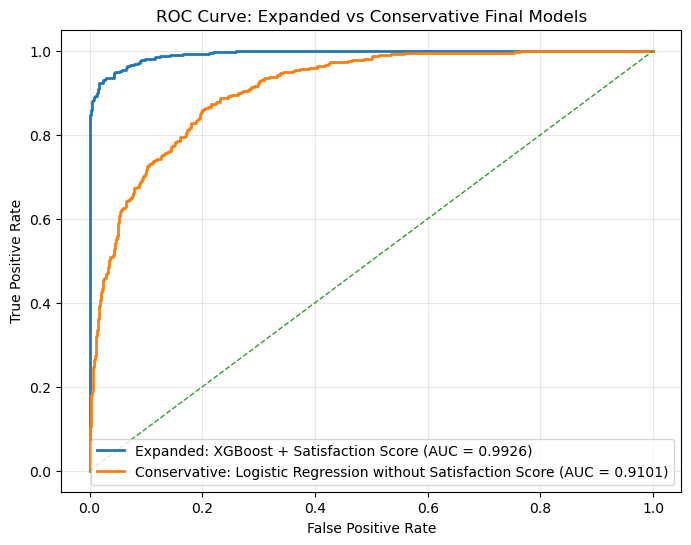

In [136]:
# Expanded final model
fpr_exp, tpr_exp, _ = roc_curve(y_test, xgb_y_proba)
roc_auc_exp = auc(fpr_exp, tpr_exp)

# Conservative final model
fpr_cons, tpr_cons, _ = roc_curve(y_test_ns, logreg_y_proba_ns)
roc_auc_cons = auc(fpr_cons, tpr_cons)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr_exp, tpr_exp,
    linewidth=2,
    label=f"Expanded: XGBoost + Satisfaction Score (AUC = {roc_auc_exp:.4f})"
)
plt.plot(
    fpr_cons, tpr_cons,
    linewidth=2,
    label=f"Conservative: Logistic Regression without Satisfaction Score (AUC = {roc_auc_cons:.4f})"
)
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Expanded vs Conservative Final Models")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

The ROC curves show that the expanded model achieves substantially stronger class separation. However, because this performance depends heavily on `Satisfaction Score`, the conservative curve provides a more realistic view of deployable performance.

### 20.2 Metric comparison between final model views

This chart compares the expanded and conservative final views across the main evaluation metrics.

It helps show how much performance changes once `Satisfaction Score` is removed from the modeling pipeline.

In [137]:
comparison_plot_df = pd.DataFrame({
    "metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Expanded Model": [
        xgb_results["test_accuracy"],
        xgb_results["test_precision"],
        xgb_results["test_recall"],
        xgb_results["test_f1"],
        xgb_results["test_roc_auc"]
    ],
    "Conservative Model": [
        logreg_no_sat_results["test_accuracy"],
        logreg_no_sat_results["test_precision"],
        logreg_no_sat_results["test_recall"],
        logreg_no_sat_results["test_f1"],
        logreg_no_sat_results["test_roc_auc"]
    ]
})

comparison_plot_df.round(4)

,metric,Expanded Model,Conservative Model
0,Accuracy,0.9638,0.8524
1,Precision,0.9628,0.7441
2,Recall,0.8984,0.6765
3,F1-score,0.9295,0.7087
4,ROC-AUC,0.9926,0.9101


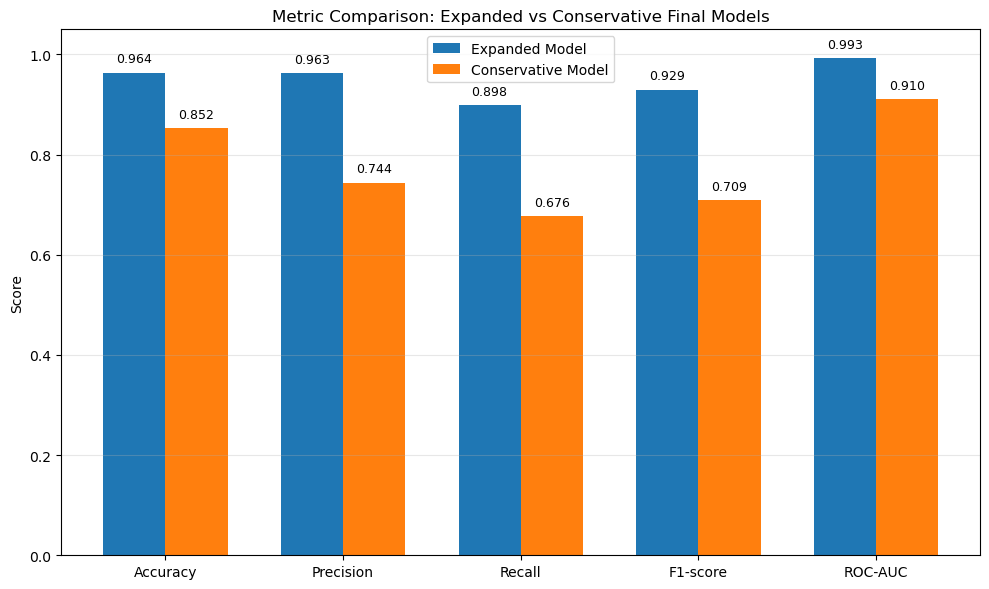

In [142]:
x = np.arange(len(comparison_plot_df["metric"]))
width = 0.35

plt.figure(figsize=(10, 6))

bars1 = plt.bar(
    x - width/2,
    comparison_plot_df["Expanded Model"],
    width,
    label="Expanded Model"
)

bars2 = plt.bar(
    x + width/2,
    comparison_plot_df["Conservative Model"],
    width,
    label="Conservative Model"
)

plt.xticks(x, comparison_plot_df["metric"])
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Metric Comparison: Expanded vs Conservative Final Models")
plt.legend()
plt.grid(axis="y", alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.015,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

for bar in bars2:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.015,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

The metric comparison highlights a clear performance gap between the expanded and conservative final model views.

The expanded model performs better across all major metrics, especially in precision, recall, F1-score, and ROC-AUC. However, this stronger performance depends heavily on `Satisfaction Score`.

By contrast, the conservative model delivers lower scores but provides a more realistic and deployment-oriented benchmark once this high-impact feature is removed.

### 20.3 Feature importance in the expanded XGBoost model

The feature importance chart helps identify which variables drive the expanded XGBoost model most strongly.

If `Satisfaction Score` dominates the ranking, this visually supports the earlier sensitivity findings by showing that the model relies heavily on a single high-impact feature.

In [139]:
expanded_pipeline = best_xgb_model

feature_names = expanded_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = expanded_pipeline.named_steps["classifier"].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feature_importance_df.head(15)

,feature,importance
12,num__Satisfaction Score,0.423126
55,cat__Contract_Month-to-Month,0.111341
57,cat__Contract_Two Year,0.042870
39,cat__Online Security_No,0.039031
40,cat__Online Security_Yes,0.035695
17,cat__Senior Citizen_No,0.025563
34,cat__Internet Service_No,0.023673
56,cat__Contract_One Year,0.018394
3,num__Number of Referrals,0.016569
18,cat__Senior Citizen_Yes,0.014146


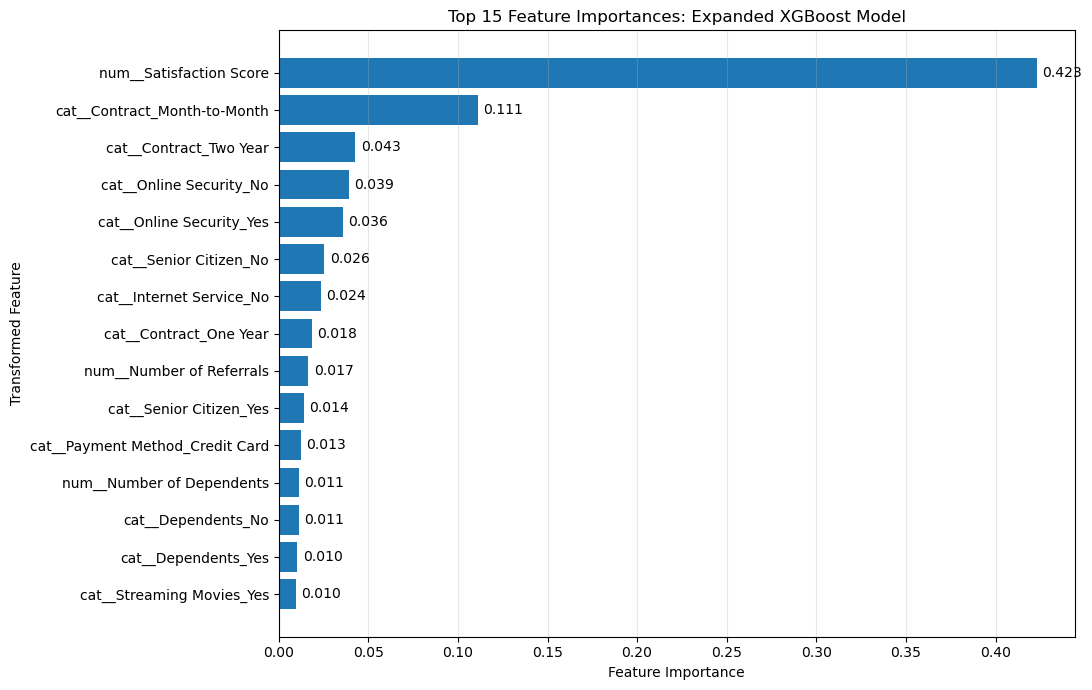

In [141]:
top_features = feature_importance_df.head(15).sort_values(by="importance", ascending=True)

plt.figure(figsize=(11, 7))
bars = plt.barh(top_features["feature"], top_features["importance"])

plt.xlabel("Feature Importance")
plt.ylabel("Transformed Feature")
plt.title("Top 15 Feature Importances: Expanded XGBoost Model")
plt.grid(axis="x", alpha=0.3)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.003, bar.get_y() + bar.get_height()/2, f"{width:.3f}", va="center")

plt.tight_layout()
plt.show()

The feature importance chart shows that `Satisfaction Score` dominates the expanded XGBoost model by a wide margin. This supports the earlier sensitivity findings and indicates that the model relies heavily on a single high-impact feature.

Because the final predictive performance changes substantially once this variable is removed, `Satisfaction Score` is treated as a high-impact review feature rather than a fully reliable deployment feature.

### 21. Final interpretation

- **Expanded Model (sensitivity / high-performance view):**  
  This version achieved stronger predictive performance, but its results depend heavily on `Satisfaction Score`. Because the business timing and deployability of this variable are not fully verified, this version should be interpreted cautiously.

- **Conservative Model (final recommendation):**  
  After removing `Satisfaction Score`, the final conservative comparison showed that **Logistic Regression without `Satisfaction Score`** provided the most defensible balance between recall and F1-score. Although its performance was lower, it offers a more realistic and deployable result.

### 22. Final recommendation

For real business use and final project reporting, the **Conservative Model** is recommended as the primary final model.

The expanded model can still be retained as a sensitivity case study to demonstrate how strongly performance changes when a high-impact review feature is included.